# V5 - input from file

In [ ]:
from ipycanvas import Canvas
import ipywidgets as widgets
from IPython.display import display
import numpy as np
import random
from collections import defaultdict
import math

# List of possible goals --- 6 shapes (add more?)
GOAL_SHAPES = {
    "square": [(i, j) for i in range(3) for j in range(3)],
    "line": [(0, i - 4) for i in range(9)],
    "L": [
        (-2, 0), (-1, 0), (0, 0), (1, 0), (2, 0),
        (-2, 1), (-2, 2), (-2, 3), (-2, 4)
    ],
    "U": [
        (-2, 0), (-1, 0), (0, 0), (1, 0), (2, 0),
        (-2, 1), (-2, 2),
        (2, 1), (2, 2)
    ],
    "cross": [
        (0, -2), (0, -1), (0, 0), (0, 1), (0, 2),
        (-2, 0), (-1, 0), (1, 0), (2, 0)
    ],
    "stack": [
        (-2, 0), (-1, 0), (0, 0), (1, 0), (2, 0),
        (-1, 1), (0, 1), (1, 1),
        (0, 2)
    ]
}


#_______________________________________________________________________________
class POMCPNode:
    def __init__(self, action=None, parent=None):
        self.action = action
        self.parent = parent
        self.children = {}
        self.visit_count = 0
        self.value_sum = 0.0
        self.particles = []
        
    def is_leaf(self):
        return len(self.children) == 0
        
    def ucb_value(self, c=1.4):
        if self.visit_count == 0:
            return float('inf')
        exploitation = self.value_sum / self.visit_count
        exploration = c * math.sqrt(math.log(self.parent.visit_count) / self.visit_count)
        return exploitation + exploration

#_______________________________________________________________________________

class ParticleFilter:
    def __init__(self, goals=None):
        self.goals = goals or list(GOAL_SHAPES.keys())
        self.particles = []
        self.reset()
    
    def reset(self):
        """Reset particles to uniform distribution over all goals"""
        self.particles = [random.choice(self.goals) for _ in range(500)]
    
    def update(self, observation, likelihood_fn):
        """Update particles based on observation using likelihood function"""
        if not self.particles:
            return
            
        # Calculate weights for each particle
        weights = []
        for particle in self.particles:
            weight = likelihood_fn(particle, observation)
            weights.append(weight)
        
        # Handle degenerate case where all weights are zero
        total_weight = sum(weights)
        if total_weight == 0:
            print("(Resetting to uniform distribution)")
            self.reset()
            return
        
        # Normalize weights
        weights = [w / total_weight for w in weights]
        
        # Handle edge case where weights are too small for reliable resampling
        if max(weights) < 1e-10:
            print("Warning: Particle weights too small. Resetting to uniform distribution.")
            self.reset()
            return
        
        # Resample particles based on weights 
        new_particles = []
        n = len(self.particles)
        
        # Systematic resampling - more stable than naive approach
        positions = [(i + np.random.random()) / n for i in range(n)]
        cumulative_weights = np.cumsum(weights)
        
        i, j = 0, 0
        while i < n and j < len(cumulative_weights):
            if positions[i] < cumulative_weights[j]:
                new_particles.append(self.particles[j])
                i += 1
            else: j += 1
        
        # Fallback if systematic resampling fails
        if len(new_particles) != len(self.particles):
            print("Warning: Systematic resampling failed. Using multinomial resampling.")
            # Multinomial resampling as fallback
            indices = np.random.choice(len(self.particles), size=len(self.particles), p=weights)
            new_particles = [self.particles[i] for i in indices]
        
        self.particles = new_particles
    
    def get_belief(self):
        """Get current belief distribution over goals"""
        if not self.particles:return {}
        belief = defaultdict(int)
        for particle in self.particles:
            belief[particle] += 1
        total = len(self.particles)
        return {goal: count/total for goal, count in belief.items()}

#_______________________________________________________________________________

class POMCP:
    def __init__(self, game_state, particle_filter, gamma=0.95, c=1.4):
        self.game_state = game_state
        self.particle_filter = particle_filter
        self.gamma = gamma  # discount factor
        self.c = c  # UCB exploration parameter
        self.root = None
        
    def search(self, num_simulations=100):
        """Run POMCP search to find best action"""
        self.root = POMCPNode()
        self.root.particles = self.particle_filter.particles.copy()
        
        for _ in range(num_simulations):
            self.simulate(self.root, 0)
        
        # Return best action based on visit counts
        if not self.root.children:
            return None
            
        best_action = max(self.root.children.keys(), 
                         key=lambda a: self.root.children[a].visit_count)
        return best_action
    
    def simulate(self, node, depth):
        """Simulate one path through the tree"""
        if depth > 10:  # max depth
            return 0
        
        if node.is_leaf():
            # FIXED: Expand the leaf by creating children for all possible actions
            # instead of immediately rolling out
            self.expand_node(node)
            if node.is_leaf():  # Still a leaf after expansion attempt
                return self.rollout(node, depth)
        
        action = self.select_action(node)
        
        if action not in node.children:
            # This shouldn't happen after expand_node, but safety check
            node.children[action] = POMCPNode(action, node)
        
        child = node.children[action]
        
        # Update child's particles based on action (particle filtering)
        child.particles = self.update_particles(node.particles, action)
        
        reward = self.get_reward(action, node.particles)
        future_value = self.simulate(child, depth + 1)
        total_value = reward + self.gamma * future_value
        
        node.visit_count += 1
        node.value_sum += total_value
        
        return total_value
    
    def expand_node(self, node):
        """Expand a leaf node by adding all possible actions as children"""
        possible_actions = ['suggest', 'wait']
        for action in possible_actions:
            if action not in node.children:
                node.children[action] = POMCPNode(action, node)
    
    def update_particles(self, parent_particles, action):
        """Update particles based on action taken - simulate belief evolution"""
        if action == 'wait':
            new_particles = parent_particles.copy()
            # Add small amount of noise - some particles might drift to other goals
            noise_rate = 0.05  # 5% of particles get randomized
            num_noise = int(len(new_particles) * noise_rate)
            
            for i in range(num_noise):
                idx = np.random.randint(len(new_particles))
                new_particles[idx] = np.random.choice(list(GOAL_SHAPES.keys()))

            return new_particles
            
        elif action == 'suggest':
            new_particles = []
            
            # Get current belief distribution
            belief = {}
            for particle in parent_particles:
                belief[particle] = belief.get(particle, 0) + 1
            
            for goal, count in belief.items():
                prob = count / len(parent_particles)
                overlap = self.game_state.calculate_overlap(goal)
                
                # Higher overlap goals become more likely after suggestion
                # (simulating the effect of observing the suggestion quality)
                if overlap > 0.3:
                    # Good overlap - increase probability
                    new_prob = min(0.8, prob * (1 + overlap))
                else:
                    # Poor overlap - decrease probability  
                    new_prob = max(0.1, prob * (1 - overlap * 0.5))
                
                # Add particles proportional to new probability
                num_particles = int(new_prob * len(parent_particles))
                new_particles.extend([goal] * num_particles)
            
            # Pad or truncate to maintain particle count
            while len(new_particles) < len(parent_particles):
                new_particles.append(np.random.choice(list(GOAL_SHAPES.keys())))
            new_particles = new_particles[:len(parent_particles)]
            
            # Shuffle to avoid ordering bias
            np.random.shuffle(new_particles)
            return new_particles
        
        else:
            # Unknown action - just copy
            return parent_particles.copy()
    
    def select_action(self, node):
        """Select action using UCB"""
        if not node.children:
            # Return random action from available actions
            return random.choice(['suggest', 'wait'])
        
        return max(node.children.keys(), 
                  key=lambda a: node.children[a].ucb_value(self.c))
    
    def rollout(self, node, depth):
        """Random rollout from current node - no threshold-based bias"""
        if depth > 5:  # Shorter rollouts for faster decisions
            return 0
        
        # Pure random choice - let RL learn the optimal policy
        action = np.random.choice(['suggest', 'wait'])
            
        reward = self.get_reward(action, node.particles)
        return reward + self.gamma * self.rollout(node, depth + 1)
    
    def get_reward(self, action, particles):
        """Get reward for action - learning-based approach with experience replay"""
        if action == 'wait':
            return -0.05  # Small cost for waiting
        elif action == 'suggest':
            # Use learned reward model based on historical data
            belief = self.get_particle_belief(particles)
            if not belief:
                return -1.0  # No belief = bad suggestion
            
            # Calculate features for reward prediction
            max_belief = max(belief.values())
            best_goal = max(belief.keys(), key=lambda g: belief[g])
            overlap = self.game_state.calculate_overlap(best_goal)
            
            # Simple learned model (in practice this would be updated from experience)
            # Features: [max_belief, overlap, belief_entropy]
            belief_entropy = -sum(p * np.log(p + 1e-10) for p in belief.values())
            
            # Linear reward model (coefficients would be learned from data)
            expected_reward = (
                2.0 * max_belief +      # Higher confidence = better
                3.0 * overlap +         # Higher overlap = better  
                -0.5 * belief_entropy   # Lower entropy = more certain
                - 1.0                   # Base cost of suggesting
            )
            
            return expected_reward
        
        return 0
    
    def get_particle_belief(self, particles):
        """Convert particle list to belief distribution"""
        if not particles:
            return {}
        belief = defaultdict(int)
        for particle in particles:
            belief[particle] += 1
        total = len(particles)
        return {goal: count/total for goal, count in belief.items()}

#_______________________________________________________________________________

class SimpleBlockMover:
    def __init__(self, canvas, size=40):
        self.canvas = canvas
        self.size = size
        self.blocks = []
        
        # Automatically load blocks from INPUT.dat
        self.load_blocks_from_file("INPUT.dat")
        
        self.selected = None  # Keep for visual feedback, but no interaction
        self.goal_shape = None
        
        # POMCP and particle filter
        self.particle_filter = ParticleFilter()
        self.pomcp = POMCP(self, self.particle_filter)
        
        # AI suggestion state
        self.suggested_goal = None
        self.suggested_move = None
        self.suggestion_active = False
        self.last_red_pos = (self.blocks[0]['x'], self.blocks[0]['y'], self.blocks[0]['theta'])
        
        # Learning components - track experience for reward model updates
        self.experience_buffer = []  # Store (state, action, reward) tuples
        self.reward_model_params = {
            'belief_weight': 2.0,
            'overlap_weight': 3.0, 
            'entropy_weight': -0.5,
            'base_cost': -1.0
        }
        self.total_reward = 0

        # Remove mouse event handlers - blocks are no longer interactive
        self.draw()

    def load_blocks_from_file(self, filename):
        """Load block positions from a text file"""
        # Reset blocks list to avoid accumulation
        self.blocks = []
        
        try:
            with open(filename, 'r') as f:
                lines = f.readlines()
            
            for i, line in enumerate(lines):
                line = line.strip()
                if not line or line.startswith('#'):
                    continue  # Skip empty lines and comments
                
                parts = line.split()
                if len(parts) >= 3:
                    x = float(parts[0])
                    y = float(parts[1])
                    theta = float(parts[2]) if len(parts) > 2 else 0.0
                    color = 'red' if len(self.blocks) == 0 else 'black'  # First block is red
                    self.blocks.append({'x': x, 'y': y, 'theta': theta, 'color': color})
                    
                if len(self.blocks) >= 9:  # Limit to 9 blocks
                    break
            
            # Ensure we have exactly 9 blocks
            while len(self.blocks) < 9:
                # Add random blocks if file doesn't have enough
                x = np.random.randint(self.size, self.canvas.width - self.size)
                y = np.random.randint(self.size, self.canvas.height - self.size)
                theta = np.random.uniform(-np.pi, np.pi)
                color = 'red' if len(self.blocks) == 0 else 'black'
                self.blocks.append({'x': x, 'y': y, 'theta': theta, 'color': color})
                
            print(f"Loaded {len(self.blocks)} blocks from {filename}")
            
        except FileNotFoundError:
            print(f"File {filename} not found. Generating random positions.")
            # Fallback to random generation
            for i in range(9):
                x = np.random.randint(self.size, self.canvas.width - self.size)
                y = np.random.randint(self.size, self.canvas.height - self.size)
                theta = np.random.uniform(-np.pi, np.pi)
                color = 'red' if i == 0 else 'black'
                self.blocks.append({'x': x, 'y': y, 'theta': theta, 'color': color})
        except Exception as e:
            print(f"Error loading file {filename}: {e}")
            # Fallback to random generation
            for i in range(9):
                x = np.random.randint(self.size, self.canvas.width - self.size)
                y = np.random.randint(self.size, self.canvas.height - self.size)
                theta = np.random.uniform(-np.pi, np.pi)
                color = 'red' if i == 0 else 'black'
                self.blocks.append({'x': x, 'y': y, 'theta': theta, 'color': color})

    def save_positions_to_file(self, filename="OUTPUT.dat", mode="current"):
        """Save block positions to OUTPUT.dat"""
        with open(filename, 'w') as f:
            f.write(f"# Block positions - {mode} state\n")
            f.write("# Format: x y theta (one block per line)\n")
            f.write("# First block is red (reference block)\n")
            
            if mode == "goal_accepted":
                # Write goal shape positions relative to red block
                red = [b for b in self.blocks if b['color'] == 'red'][0]
                x0, y0, theta = red['x'], red['y'], red['theta']
                
                goal_positions = []
                for (dx, dy) in GOAL_SHAPES[self.suggested_goal]:
                    c, sn = np.cos(theta), np.sin(theta)
                    X = x0 + (dx * self.size * c - dy * self.size * sn)
                    Y = y0 + (dx * self.size * sn + dy * self.size * c)
                    goal_positions.append((X, Y, theta))
                
                for i, (x, y, t) in enumerate(goal_positions):
                    f.write(f"{x:.1f} {y:.1f} {t:.3f}\n")
                    
            else:  # current or move_accepted
                for i, block in enumerate(self.blocks):
                    f.write(f"{block['x']:.1f} {block['y']:.1f} {block['theta']:.3f}\n")
        
        print(f"Block positions ({mode}) saved to {filename}")

    def check_red_block_moved(self):
        """Check if red block moved and reset particle filter if so"""
        # Since blocks can't move interactively anymore, this is mainly for consistency
        return False

    def update_beliefs_from_move(self, moved_block_idx):
        """Update particle filter based on move (kept for compatibility)"""
        def likelihood(goal, observation):
            """Likelihood that human would make this move given this goal"""
            block_idx, _ = observation
            
            # Calculate how much this move improves overlap for this goal
            current_overlap = self.calculate_overlap(goal)
            
            # Humans are more likely to move blocks that improve their suspected goal
            if current_overlap > 0.3:
                return min(1.0, current_overlap * 2)
            else:
                return 0.1  # low but non-zero baseline
        
        observation = (moved_block_idx, self.blocks[moved_block_idx])
        self.particle_filter.update(observation, likelihood)

    def pomcp_decide_action(self):
        """Use POMCP to decide whether to suggest or wait"""
        # Update POMCP with current game state
        self.pomcp.game_state = self
        self.pomcp.particle_filter = self.particle_filter
        
        action = self.pomcp.search(num_simulations=200)  # Increased simulations
        
        belief = self.particle_filter.get_belief()
        
        # Debug info without manual override
        if action:
            suggest_reward = self.pomcp.get_reward('suggest', self.particle_filter.particles)
            wait_reward = self.pomcp.get_reward('wait', self.particle_filter.particles)
            print(f"Current beliefs: {belief}")
            print(f"Expected rewards - Suggest: {suggest_reward:.2f}, Wait: {wait_reward:.2f}")
            print(f"POMCP decision: {action}")
        else:
            print("POMCP search returned None - tree expansion failed")
            # Fallback to simple heuristic
            max_belief = max(belief.values()) if belief else 0
            if max_belief > 0.4:  # Simple threshold
                action = 'suggest'
            else:
                action = 'wait'
            print(f"Fallback decision: {action}")
        
        return action

    def make_pomcp_suggestion(self):
        """Use POMCP to decide whether to make a suggestion"""
        action = self.pomcp_decide_action()
        
        if action == 'suggest':
            # Find best goal based on current belief and overlaps
            belief = self.particle_filter.get_belief()
            best_goal = None
            best_score = -1
            
            # Pure RL approach - no thresholds, just pick the best scoring goal
            for goal, prob in belief.items():
                overlap = self.calculate_overlap(goal)
                score = prob * overlap
                if score > best_score:
                    best_score = score
                    best_goal = goal
            
            # Always suggest if POMCP decided to suggest, regardless of overlap
            if best_goal:
                move = self.find_beneficial_move(best_goal)
                self.suggested_goal = best_goal
                self.suggested_move = move
                self.suggestion_active = True
                print(f"AI suggests goal '{best_goal}' (belief: {belief.get(best_goal, 0):.1%}, overlap: {self.calculate_overlap(best_goal):.1%})")
                if move:
                    print(f"Suggested move: Block {move['block_idx']} to ({move['target_x']:.0f}, {move['target_y']:.0f})")
                return True
            else:
                print("POMCP decided to suggest but no goal found")
                return False
        else:  # action == 'wait'
            self.suggestion_active = False
            print("POMCP decided to wait for more moves")
            return False

    def process_human_feedback(self, feedback, reward):
        """Process human feedback and update learning"""
        self.total_reward += reward
        
        # Store experience for reward model learning
        belief = self.particle_filter.get_belief()
        if belief:
            max_belief = max(belief.values())
            best_goal = max(belief.keys(), key=lambda g: belief[g])
            overlap = self.calculate_overlap(best_goal)
            belief_entropy = -sum(p * np.log(p + 1e-10) for p in belief.values())
            
            experience = {
                'max_belief': max_belief,
                'overlap': overlap,
                'entropy': belief_entropy,
                'action': 'suggest',
                'reward': reward,
                'feedback': feedback
            }
            self.experience_buffer.append(experience)
            
            # Simple online learning update (in practice would use batch updates)
            self.update_reward_model(experience)
        
        print(f"Feedback: {feedback}, Reward: {reward:+.1f}, Total: {self.total_reward:.1f}")
        
        if feedback == 'accept_goal':
            # Strong positive update for the suggested goal
            def likelihood(goal, observation):
                if goal == self.suggested_goal:
                    return 10.0  # Very high likelihood
                else:
                    return 0.1   # Very low likelihood for other goals
            
            self.particle_filter.update(None, likelihood)
            print(f"Goal '{self.suggested_goal}' accepted - strong belief update")
            
        elif feedback == 'accept_move':
            # Moderate positive update
            def likelihood(goal, observation):
                if goal == self.suggested_goal:
                    return 3.0   # Higher likelihood 
                else:
                    return 0.5   # Lower likelihood for other goals
            
            self.particle_filter.update(None, likelihood)
            
        elif feedback == 'reject':
            # Negative update - reduce belief in suggested goal
            def likelihood(goal, observation):
                if goal == self.suggested_goal:
                    return 0.1   # Much lower likelihood
                else:
                    return 1.0   # Maintain likelihood for other goals
            
            self.particle_filter.update(None, likelihood)
    
    def update_reward_model(self, experience):
        """Simple online update of reward model parameters"""
        learning_rate = 0.1
        actual_reward = experience['reward']
        
        # Predict reward using current model
        predicted_reward = (
            self.reward_model_params['belief_weight'] * experience['max_belief'] +
            self.reward_model_params['overlap_weight'] * experience['overlap'] +
            self.reward_model_params['entropy_weight'] * experience['entropy'] +
            self.reward_model_params['base_cost']
        )
        
        # Update parameters based on prediction error
        error = actual_reward - predicted_reward
        self.reward_model_params['belief_weight'] += learning_rate * error * experience['max_belief']
        self.reward_model_params['overlap_weight'] += learning_rate * error * experience['overlap'] 
        self.reward_model_params['entropy_weight'] += learning_rate * error * experience['entropy']
        
        print(f"Reward model updated. Error: {error:.2f}, Params: {self.reward_model_params}")

    def draw(self):
        self.canvas.clear()
        s = self.size
        
        # draw all blocks
        for i, b in enumerate(self.blocks):
            self.canvas.save()
            self.canvas.translate(b['x'], b['y'])
            self.canvas.rotate(b['theta'])
            
            # highlight suggested block to move
            if (self.suggestion_active and self.suggested_move and 
                i == self.suggested_move['block_idx']):
                self.canvas.fill_style = 'yellow'
            else:
                self.canvas.fill_style = b['color']
                
            self.canvas.fill_rect(-s/2, -s/2, s, s)
            
            # Remove interactive selection highlighting since blocks can't be moved
            self.canvas.restore()

        # draw goal shape (manual selection)
        if self.goal_shape and not self.suggestion_active:
            self.draw_goal_shape(self.goal_shape, 'blue', 0.3)
            
        # draw suggested goal shape in green
        if self.suggestion_active and self.suggested_goal:
            self.draw_goal_shape(self.suggested_goal, 'green', 0.4)
            
        # draw suggested move target
        if (self.suggestion_active and self.suggested_move):
            self.canvas.save()
            self.canvas.global_alpha = 0.6
            self.canvas.fill_style = 'lime'
            self.canvas.translate(self.suggested_move['target_x'], self.suggested_move['target_y'])
            self.canvas.fill_rect(-s/2, -s/2, s, s)
            self.canvas.restore()

        # Display current beliefs
        belief = self.particle_filter.get_belief()
        if belief:
            text = "Beliefs: " + ", ".join([f"{g}:{p:.1%}" for g, p in sorted(belief.items(), key=lambda x: x[1], reverse=True)[:3]])
            self.canvas.fill_style = 'black'
            self.canvas.font = '12px Arial'
            self.canvas.fill_text(text, 10, 20)

    def draw_goal_shape(self, name, color, alpha):
        # find the red block as anchor
        red = [b for b in self.blocks if b['color'] == 'red'][0]
        x0, y0, theta = red['x'], red['y'], red['theta']

        s = self.size
        self.canvas.global_alpha = alpha
        self.canvas.fill_style = color

        for (dx, dy) in GOAL_SHAPES[name]:
            # rotate offset (dx,dy) by theta
            c, sn = np.cos(theta), np.sin(theta)
            X = x0 + (dx * s * c - dy * s * sn)
            Y = y0 + (dx * s * sn + dy * s * c)

            self.canvas.save()
            self.canvas.translate(X, Y)
            self.canvas.rotate(theta)
            self.canvas.fill_rect(-s/2, -s/2, s, s)
            self.canvas.restore()

        self.canvas.global_alpha = 1.0

    def calculate_overlap(self, goal_name):
        """Calculate overlap percentage between current blocks and a goal shape"""
        red = [b for b in self.blocks if b['color'] == 'red'][0]
        x0, y0, theta = red['x'], red['y'], red['theta']
        
        goal_positions = []
        for (dx, dy) in GOAL_SHAPES[goal_name]:
            c, sn = np.cos(theta), np.sin(theta)
            X = x0 + (dx * self.size * c - dy * self.size * sn)
            Y = y0 + (dx * self.size * sn + dy * self.size * c)
            goal_positions.append((X, Y))
        
        # Check which goal positions have overlapping blocks
        overlapped = 0
        overlap_threshold_dist = self.size * 0.7
        
        for goal_x, goal_y in goal_positions:
            for block in self.blocks:
                dist = np.sqrt((block['x'] - goal_x)**2 + (block['y'] - goal_y)**2)
                if dist <= overlap_threshold_dist:
                    overlapped += 1
                    break
        
        return overlapped / len(goal_positions) if goal_positions else 0

    def find_beneficial_move(self, goal_name):
        """Find a move that would improve overlap for the given goal"""
        red = [b for b in self.blocks if b['color'] == 'red'][0]
        x0, y0, theta = red['x'], red['y'], red['theta']
        
        # Get goal positions
        goal_positions = []
        for (dx, dy) in GOAL_SHAPES[goal_name]:
            c, sn = np.cos(theta), np.sin(theta)
            X = x0 + (dx * self.size * c - dy * self.size * sn)
            Y = y0 + (dx * self.size * sn + dy * self.size * c)
            goal_positions.append((X, Y))
        
        # Find unoccupied goal positions
        overlap_threshold_dist = self.size * 0.7
        unoccupied_goals = []
        
        for goal_x, goal_y in goal_positions:
            occupied = False
            for block in self.blocks:
                dist = np.sqrt((block['x'] - goal_x)**2 + (block['y'] - goal_y)**2)
                if dist <= overlap_threshold_dist:
                    occupied = True
                    break
            if not occupied:
                unoccupied_goals.append((goal_x, goal_y))
        
        if not unoccupied_goals:
            return None
            
        # Find non-overlapped blocks
        non_overlapped_blocks = []
        for i, block in enumerate(self.blocks):
            is_overlapped = False
            for goal_x, goal_y in goal_positions:
                dist = np.sqrt((block['x'] - goal_x)**2 + (block['y'] - goal_y)**2)
                if dist <= overlap_threshold_dist:
                    is_overlapped = True
                    break
            if not is_overlapped:
                non_overlapped_blocks.append(i)
        
        if not non_overlapped_blocks:
            return None
            
        # Suggest moving a random non-overlapped block to a random unoccupied goal
        block_idx = np.random.choice(non_overlapped_blocks)
        target_x, target_y = unoccupied_goals[np.random.randint(len(unoccupied_goals))]
        
        return {
            'block_idx': block_idx,
            'target_x': target_x,
            'target_y': target_y
        }

    def accept_goal(self):
        """Accept the suggested goal - end episode and save goal positions"""
        if self.suggestion_active:
            reward = 10.0  # Large positive reward
            self.process_human_feedback('accept_goal', reward)
            print(f"Episode completed! Goal '{self.suggested_goal}' accepted.")
            
            # Save goal positions to OUTPUT.dat
            self.save_positions_to_file("OUTPUT.dat", "goal_accepted")
            
            self.suggestion_active = False
            self.goal_shape = self.suggested_goal
            self.draw()

    def accept_move(self):
        """Accept and apply the suggested move and save updated positions"""
        if self.suggestion_active and self.suggested_move:
            reward = 2.0  # Moderate positive reward
            self.process_human_feedback('accept_move', reward)
            
            move = self.suggested_move
            self.blocks[move['block_idx']]['x'] = move['target_x']
            self.blocks[move['block_idx']]['y'] = move['target_y']
            print(f"Applied suggested move. Block positions updated.")
            
            # Save updated positions to OUTPUT.dat
            self.save_positions_to_file("OUTPUT.dat", "move_accepted")
            
            self.suggestion_active = False
            self.draw()

    def reject_suggestion(self):
        """Reject the suggestion and continue"""
        if self.suggestion_active:
            reward = -1.0  # Negative reward
            self.process_human_feedback('reject', reward)
            print("Suggestion rejected.")
            self.suggestion_active = False
            self.draw()


# Create the game - automatically loads from INPUT.dat
canvas = Canvas(width=600, height=600,
                layout=widgets.Layout(width="500px", height="500px",
                                      border="2px solid black"))

mover = SimpleBlockMover(canvas)

# File controls
btn_save = widgets.Button(description='Save Sample File', button_style='info')
btn_reload = widgets.Button(description='Reload INPUT.dat', button_style='warning')

def save_sample(_):
    mover.save_positions_to_file("sample_blocks.txt", "current")

def reload_from_file(_):
    mover.load_blocks_from_file("INPUT.dat")
    mover.draw()

btn_save.on_click(save_sample)
btn_reload.on_click(reload_from_file)

# Manual goal selection
goal_dropdown = widgets.Dropdown(options=list(GOAL_SHAPES.keys()), description="Manual Goal:")
def set_goal(change):
    if not mover.suggestion_active:  # Only allow manual goal when no suggestion active
        mover.goal_shape = change['new']
        mover.draw()
goal_dropdown.observe(set_goal, names='value')

# AI interaction buttons
btn_done = widgets.Button(description='ANALYZE', button_style='info')
btn_accept_goal = widgets.Button(description='Accept Goal', button_style='success')
btn_accept_move = widgets.Button(description='Accept Move', button_style='warning')
btn_reject = widgets.Button(description='Reject', button_style='danger')

def on_done_clicked(_):
    suggestion_made = mover.make_pomcp_suggestion()
    mover.draw()
    # Show/hide suggestion buttons based on whether suggestion was made
    btn_accept_goal.layout.visibility = 'visible' if suggestion_made else 'hidden'
    btn_accept_move.layout.visibility = 'visible' if (suggestion_made and mover.suggested_move) else 'hidden'
    btn_reject.layout.visibility = 'visible' if suggestion_made else 'hidden'

def on_accept_goal(_):
    mover.accept_goal()
    # Hide suggestion buttons
    for btn in [btn_accept_goal, btn_accept_move, btn_reject]:
        btn.layout.visibility = 'hidden'

def on_accept_move(_):
    mover.accept_move()
    # Hide suggestion buttons
    for btn in [btn_accept_goal, btn_accept_move, btn_reject]:
        btn.layout.visibility = 'hidden'

def on_reject(_):
    mover.reject_suggestion()
    # Hide suggestion buttons
    for btn in [btn_accept_goal, btn_accept_move, btn_reject]:
        btn.layout.visibility = 'hidden'

btn_done.on_click(on_done_clicked)
btn_accept_goal.on_click(on_accept_goal)
btn_accept_move.on_click(on_accept_move)
btn_reject.on_click(on_reject)

# Initially hide suggestion buttons
for btn in [btn_accept_goal, btn_accept_move, btn_reject]:
    btn.layout.visibility = 'hidden'

# Layout
file_controls = widgets.HBox([btn_save, btn_reload])
controls1 = widgets.HBox([goal_dropdown])
controls2 = widgets.HBox([btn_done])
controls3 = widgets.HBox([btn_accept_goal, btn_accept_move, btn_reject])

# Instructions
instructions = widgets.HTML(value="""
<b>Infer blocks positions:</b><br>
1. Blocks loaded from 'INPUT.dat' (x y theta, one per line)<br>
2. First block will be red (reference block), others black<br>
--> positions are saved to 'OUTPUT.dat'
""")

display(widgets.VBox([instructions, canvas, file_controls, controls1, controls2, controls3]))

print("Block mover initialized. Loaded from INPUT.dat automatically.")

File INPUT.dat not found. Generating random positions.


Block mover initialized. Loaded from INPUT.dat automatically.


# ----- Other things

## V4 bis - interactive


In [ ]:
from ipycanvas import Canvas
import ipywidgets as widgets
from IPython.display import display
import numpy as np
import random
from collections import defaultdict
import math

# Goal shapes dictionary (relative positions to red block)
GOAL_SHAPES = {
    "square": [(i, j) for i in range(3) for j in range(3)],
    "line": [(0, i - 4) for i in range(9)],
    "L": [
        (-2, 0), (-1, 0), (0, 0), (1, 0), (2, 0),
        (-2, 1), (-2, 2), (-2, 3), (-2, 4)
    ],
    "U": [
        (-2, 0), (-1, 0), (0, 0), (1, 0), (2, 0),
        (-2, 1), (-2, 2),
        (2, 1), (2, 2)
    ],
    "cross": [
        (0, -2), (0, -1), (0, 0), (0, 1), (0, 2),
        (-2, 0), (-1, 0), (1, 0), (2, 0)
    ],
    "stack": [
        (-2, 0), (-1, 0), (0, 0), (1, 0), (2, 0),
        (-1, 1), (0, 1), (1, 1),
        (0, 2)
    ]
}

class POMCPNode:
    def __init__(self, action=None, parent=None):
        self.action = action
        self.parent = parent
        self.children = {}
        self.visit_count = 0
        self.value_sum = 0.0
        self.particles = []
        
    def is_leaf(self):
        return len(self.children) == 0
        
    def ucb_value(self, c=1.4):
        if self.visit_count == 0:
            return float('inf')
        exploitation = self.value_sum / self.visit_count
        exploration = c * math.sqrt(math.log(self.parent.visit_count) / self.visit_count)
        return exploitation + exploration

class ParticleFilter:
    def __init__(self, goals=None):
        self.goals = goals or list(GOAL_SHAPES.keys())
        self.particles = []
        self.reset()
    
    def reset(self):
        """Reset particles to uniform distribution over all goals"""
        self.particles = [random.choice(self.goals) for _ in range(500)]
    
    def update(self, observation, likelihood_fn):
        """Update particles based on observation using likelihood function"""
        if not self.particles:
            return
            
        # Calculate weights for each particle
        weights = []
        for particle in self.particles:
            weight = likelihood_fn(particle, observation)
            weights.append(weight)
        
        # Handle degenerate case where all weights are zero
        total_weight = sum(weights)
        if total_weight == 0:
            print("Warning: All particle weights are zero. Resetting to uniform distribution.")
            self.reset()
            return
        
        # Normalize weights
        weights = [w / total_weight for w in weights]
        
        # Handle edge case where weights are too small for reliable resampling
        if max(weights) < 1e-10:
            print("Warning: Particle weights too small. Resetting to uniform distribution.")
            self.reset()
            return
        
        # Resample particles based on weights using systematic resampling
        new_particles = []
        n = len(self.particles)
        
        # Systematic resampling - more stable than naive approach
        positions = [(i + np.random.random()) / n for i in range(n)]
        cumulative_weights = np.cumsum(weights)
        
        i, j = 0, 0
        while i < n and j < len(cumulative_weights):
            if positions[i] < cumulative_weights[j]:
                new_particles.append(self.particles[j])
                i += 1
            else:
                j += 1
        
        # Fallback if systematic resampling fails
        if len(new_particles) != len(self.particles):
            print("Warning: Systematic resampling failed. Using multinomial resampling.")
            indices = np.random.choice(len(self.particles), size=len(self.particles), p=weights)
            new_particles = [self.particles[i] for i in indices]
        
        self.particles = new_particles
    
    def get_belief(self):
        """Get current belief distribution over goals"""
        if not self.particles:
            return {}
        belief = defaultdict(int)
        for particle in self.particles:
            belief[particle] += 1
        total = len(self.particles)
        return {goal: count/total for goal, count in belief.items()}

class POMCP:
    def __init__(self, game_state, particle_filter, gamma=0.95, c=1.4):
        self.game_state = game_state
        self.particle_filter = particle_filter
        self.gamma = gamma  # discount factor
        self.c = c  # UCB exploration parameter
        self.root = None
        
    def search(self, num_simulations=100):
        """Run POMCP search to find best action"""
        self.root = POMCPNode()
        self.root.particles = self.particle_filter.particles.copy()
        
        for _ in range(num_simulations):
            self.simulate(self.root, 0)
        
        # Return best action based on visit counts
        if not self.root.children:
            return None
            
        best_action = max(self.root.children.keys(), 
                         key=lambda a: self.root.children[a].visit_count)
        return best_action
    
    def simulate(self, node, depth):
        """Simulate one path through the tree"""
        if depth > 10:  # max depth
            return 0
        
        if node.is_leaf():
            self.expand_node(node)
            if node.is_leaf():  # Still a leaf after expansion attempt
                return self.rollout(node, depth)
        
        action = self.select_action(node)
        
        if action not in node.children:
            node.children[action] = POMCPNode(action, node)
        
        child = node.children[action]
        
        # Update child's particles based on action (particle filtering)
        child.particles = self.update_particles(node.particles, action)
        
        reward = self.get_reward(action, node.particles)
        future_value = self.simulate(child, depth + 1)
        total_value = reward + self.gamma * future_value
        
        node.visit_count += 1
        node.value_sum += total_value
        
        return total_value
    
    def expand_node(self, node):
        """Expand a leaf node by adding all possible actions as children"""
        possible_actions = ['suggest', 'wait']
        for action in possible_actions:
            if action not in node.children:
                node.children[action] = POMCPNode(action, node)
    
    def update_particles(self, parent_particles, action):
        """Update particles based on action taken - simulate belief evolution"""
        if action == 'wait':
            new_particles = parent_particles.copy()
            
            # Add small amount of noise - some particles might drift to other goals
            noise_rate = 0.05  # 5% of particles get randomized
            num_noise = int(len(new_particles) * noise_rate)
            
            for i in range(num_noise):
                idx = np.random.randint(len(new_particles))
                new_particles[idx] = np.random.choice(list(GOAL_SHAPES.keys()))
            
            return new_particles
            
        elif action == 'suggest':
            new_particles = []
            
            # Get current belief distribution
            belief = {}
            for particle in parent_particles:
                belief[particle] = belief.get(particle, 0) + 1
            
            for goal, count in belief.items():
                prob = count / len(parent_particles)
                overlap = self.game_state.calculate_overlap(goal)
                
                # Higher overlap goals become more likely after suggestion
                if overlap > 0.3:
                    new_prob = min(0.8, prob * (1 + overlap))
                else:
                    new_prob = max(0.1, prob * (1 - overlap * 0.5))
                
                # Add particles proportional to new probability
                num_particles = int(new_prob * len(parent_particles))
                new_particles.extend([goal] * num_particles)
            
            # Pad or truncate to maintain particle count
            while len(new_particles) < len(parent_particles):
                new_particles.append(np.random.choice(list(GOAL_SHAPES.keys())))
            new_particles = new_particles[:len(parent_particles)]
            
            # Shuffle to avoid ordering bias
            np.random.shuffle(new_particles)
            return new_particles
        
        else:
            return parent_particles.copy()
    
    def select_action(self, node):
        """Select action using UCB"""
        if not node.children:
            return random.choice(['suggest', 'wait'])
        
        return max(node.children.keys(), 
                  key=lambda a: node.children[a].ucb_value(self.c))
    
    def rollout(self, node, depth):
        """Random rollout from current node"""
        if depth > 5:  # Shorter rollouts for faster decisions
            return 0
        
        action = np.random.choice(['suggest', 'wait'])
        reward = self.get_reward(action, node.particles)
        return reward + self.gamma * self.rollout(node, depth + 1)
    
    def get_reward(self, action, particles):
        """Get reward for action - learning-based approach"""
        if action == 'wait':
            return -0.05  # Small cost for waiting
        elif action == 'suggest':
            belief = self.get_particle_belief(particles)
            if not belief:
                return -1.0
            
            max_belief = max(belief.values())
            best_goal = max(belief.keys(), key=lambda g: belief[g])
            overlap = self.game_state.calculate_overlap(best_goal)
            
            belief_entropy = -sum(p * np.log(p + 1e-10) for p in belief.values())
            
            expected_reward = (
                2.0 * max_belief +
                3.0 * overlap +
                -0.5 * belief_entropy
                - 1.0
            )
            
            return expected_reward
        
        return 0
    
    def get_particle_belief(self, particles):
        """Convert particle list to belief distribution"""
        if not particles:
            return {}
        belief = defaultdict(int)
        for particle in particles:
            belief[particle] += 1
        total = len(particles)
        return {goal: count/total for goal, count in belief.items()}

class SimpleBlockMover:
    def __init__(self, canvas, size=40):
        self.canvas = canvas
        self.size = size
        self.blocks = []
        
        # Initialize blocks with random positions
        self.initialize_blocks()
        
        self.selected = None
        self.dragging = False
        self.drag_start_x = 0
        self.drag_start_y = 0
        self.goal_shape = None
        
        # POMCP and particle filter
        self.particle_filter = ParticleFilter()
        self.pomcp = POMCP(self, self.particle_filter)
        
        # AI suggestion state
        self.suggested_goal = None
        self.suggested_move = None
        self.suggestion_active = False
        self.last_red_pos = (self.blocks[0]['x'], self.blocks[0]['y'], self.blocks[0]['theta'])
        
        # Learning components
        self.experience_buffer = []
        self.reward_model_params = {
            'belief_weight': 2.0,
            'overlap_weight': 3.0, 
            'entropy_weight': -0.5,
            'base_cost': -1.0
        }
        self.total_reward = 0

        # Mouse event handlers
        self.canvas.on_mouse_down(self.on_mouse_down)
        self.canvas.on_mouse_up(self.on_mouse_up)
        self.canvas.on_mouse_move(self.on_mouse_move)
        
        self.draw()

    def initialize_blocks(self):
        """Initialize blocks with random positions"""
        self.blocks = []
        for i in range(9):
            x = np.random.randint(self.size, self.canvas.width - self.size)
            y = np.random.randint(self.size, self.canvas.height - self.size)
            theta = np.random.uniform(-np.pi, np.pi)
            color = 'red' if i == 0 else 'black'
            self.blocks.append({'x': x, 'y': y, 'theta': theta, 'color': color})

    def reset_blocks(self):
        """Reset blocks to new random positions"""
        self.initialize_blocks()
        self.selected = None
        self.dragging = False
        self.goal_shape = None
        self.suggestion_active = False
        self.particle_filter.reset()
        self.draw()

    def on_mouse_down(self, x, y):
        """Handle mouse down - start dragging or rotating"""
        self.selected = None
        
        # Find block under cursor (check from top to bottom in draw order)
        for i in reversed(range(len(self.blocks))):
            block = self.blocks[i]
            dx = x - block['x']
            dy = y - block['y']
            dist = np.sqrt(dx*dx + dy*dy)
            
            if dist <= self.size/2:
                self.selected = i
                self.dragging = True
                self.drag_start_x = x
                self.drag_start_y = y
                break
        
        self.draw()

    def on_mouse_up(self, x, y):
        """Handle mouse up - stop dragging and update beliefs"""
        if self.dragging and self.selected is not None:
            self.dragging = False
            
            # Check if red block moved significantly
            if self.blocks[self.selected]['color'] == 'red':
                current_pos = (self.blocks[self.selected]['x'], 
                             self.blocks[self.selected]['y'], 
                             self.blocks[self.selected]['theta'])
                if self.position_changed(self.last_red_pos, current_pos):
                    print("Red block moved - resetting beliefs")
                    self.particle_filter.reset()
                    self.last_red_pos = current_pos
            else:
                # Update beliefs based on black block movement
                self.update_beliefs_from_move(self.selected)
            
            self.selected = None
            self.draw()

    def on_mouse_move(self, x, y):
        """Handle mouse move - drag block or rotate with right drag"""
        if self.dragging and self.selected is not None:
            # Check if this is a rotation gesture (holding shift or large horizontal movement)
            dx = x - self.drag_start_x
            dy = y - self.drag_start_y
            
            # If horizontal movement is much larger than vertical, treat as rotation
            if abs(dx) > abs(dy) * 2 and abs(dx) > 20:
                # Rotate block based on horizontal movement
                rotation_speed = 0.02
                self.blocks[self.selected]['theta'] += dx * rotation_speed
                self.drag_start_x = x  # Update drag start for continuous rotation
            else:
                # Normal dragging - move block
                self.blocks[self.selected]['x'] = max(self.size//2, min(self.canvas.width - self.size//2, x))
                self.blocks[self.selected]['y'] = max(self.size//2, min(self.canvas.height - self.size//2, y))
            
            self.draw()

    def position_changed(self, pos1, pos2, threshold=20):
        """Check if position changed significantly"""
        dx = pos1[0] - pos2[0]
        dy = pos1[1] - pos2[1]
        dtheta = abs(pos1[2] - pos2[2])
        return np.sqrt(dx*dx + dy*dy) > threshold or dtheta > 0.3

    def update_beliefs_from_move(self, moved_block_idx):
        """Update particle filter based on move"""
        def likelihood(goal, observation):
            block_idx, _ = observation
            current_overlap = self.calculate_overlap(goal)
            
            if current_overlap > 0.3:
                return min(1.0, current_overlap * 2)
            else:
                return 0.1
        
        observation = (moved_block_idx, self.blocks[moved_block_idx])
        self.particle_filter.update(observation, likelihood)

    def pomcp_decide_action(self):
        """Use POMCP to decide whether to suggest or wait"""
        self.pomcp.game_state = self
        self.pomcp.particle_filter = self.particle_filter
        
        action = self.pomcp.search(num_simulations=200)
        
        belief = self.particle_filter.get_belief()
        
        if action:
            suggest_reward = self.pomcp.get_reward('suggest', self.particle_filter.particles)
            wait_reward = self.pomcp.get_reward('wait', self.particle_filter.particles)
            print(f"Current beliefs: {belief}")
            print(f"Expected rewards - Suggest: {suggest_reward:.2f}, Wait: {wait_reward:.2f}")
            print(f"POMCP decision: {action}")
        else:
            print("POMCP search returned None - tree expansion failed")
            max_belief = max(belief.values()) if belief else 0
            if max_belief > 0.4:
                action = 'suggest'
            else:
                action = 'wait'
            print(f"Fallback decision: {action}")
        
        return action

    def make_pomcp_suggestion(self):
        """Use POMCP to decide whether to make a suggestion"""
        action = self.pomcp_decide_action()
        
        if action == 'suggest':
            belief = self.particle_filter.get_belief()
            best_goal = None
            best_score = -1
            
            for goal, prob in belief.items():
                overlap = self.calculate_overlap(goal)
                score = prob * overlap
                if score > best_score:
                    best_score = score
                    best_goal = goal
            
            if best_goal:
                move = self.find_beneficial_move(best_goal)
                self.suggested_goal = best_goal
                self.suggested_move = move
                self.suggestion_active = True
                print(f"AI suggests goal '{best_goal}' (belief: {belief.get(best_goal, 0):.1%}, overlap: {self.calculate_overlap(best_goal):.1%})")
                if move:
                    print(f"Suggested move: Block {move['block_idx']} to ({move['target_x']:.0f}, {move['target_y']:.0f})")
                return True
            else:
                print("POMCP decided to suggest but no goal found")
                return False
        else:
            self.suggestion_active = False
            print("POMCP decided to wait for more moves")
            return False

    def process_human_feedback(self, feedback, reward):
        """Process human feedback and update learning"""
        self.total_reward += reward
        
        belief = self.particle_filter.get_belief()
        if belief:
            max_belief = max(belief.values())
            best_goal = max(belief.keys(), key=lambda g: belief[g])
            overlap = self.calculate_overlap(best_goal)
            belief_entropy = -sum(p * np.log(p + 1e-10) for p in belief.values())
            
            experience = {
                'max_belief': max_belief,
                'overlap': overlap,
                'entropy': belief_entropy,
                'action': 'suggest',
                'reward': reward,
                'feedback': feedback
            }
            self.experience_buffer.append(experience)
            self.update_reward_model(experience)
        
        print(f"Feedback: {feedback}, Reward: {reward:+.1f}, Total: {self.total_reward:.1f}")
        
        if feedback == 'accept_goal':
            def likelihood(goal, observation):
                if goal == self.suggested_goal:
                    return 10.0
                else:
                    return 0.1
            
            self.particle_filter.update(None, likelihood)
            print(f"Goal '{self.suggested_goal}' accepted - strong belief update")
            
        elif feedback == 'accept_move':
            def likelihood(goal, observation):
                if goal == self.suggested_goal:
                    return 3.0
                else:
                    return 0.5
            
            self.particle_filter.update(None, likelihood)
            
        elif feedback == 'reject':
            def likelihood(goal, observation):
                if goal == self.suggested_goal:
                    return 0.1
                else:
                    return 1.0
            
            self.particle_filter.update(None, likelihood)
    
    def update_reward_model(self, experience):
        """Simple online update of reward model parameters"""
        learning_rate = 0.1
        actual_reward = experience['reward']
        
        predicted_reward = (
            self.reward_model_params['belief_weight'] * experience['max_belief'] +
            self.reward_model_params['overlap_weight'] * experience['overlap'] +
            self.reward_model_params['entropy_weight'] * experience['entropy'] +
            self.reward_model_params['base_cost']
        )
        
        error = actual_reward - predicted_reward
        self.reward_model_params['belief_weight'] += learning_rate * error * experience['max_belief']
        self.reward_model_params['overlap_weight'] += learning_rate * error * experience['overlap'] 
        self.reward_model_params['entropy_weight'] += learning_rate * error * experience['entropy']
        
        print(f"Reward model updated. Error: {error:.2f}")

    def draw(self):
        self.canvas.clear()
        s = self.size
        
        # Draw all blocks
        for i, b in enumerate(self.blocks):
            self.canvas.save()
            self.canvas.translate(b['x'], b['y'])
            self.canvas.rotate(b['theta'])
            
            # Highlight selected block
            if i == self.selected:
                self.canvas.fill_style = 'orange'
            # Highlight suggested block to move
            elif (self.suggestion_active and self.suggested_move and 
                  i == self.suggested_move['block_idx']):
                self.canvas.fill_style = 'yellow'
            else:
                self.canvas.fill_style = b['color']
                
            self.canvas.fill_rect(-s/2, -s/2, s, s)
            self.canvas.restore()

        # Draw goal shape (manual selection)
        if self.goal_shape and not self.suggestion_active:
            self.draw_goal_shape(self.goal_shape, 'blue', 0.3)
            
        # Draw suggested goal shape in green
        if self.suggestion_active and self.suggested_goal:
            self.draw_goal_shape(self.suggested_goal, 'green', 0.4)
            
        # Draw suggested move target
        if (self.suggestion_active and self.suggested_move):
            self.canvas.save()
            self.canvas.global_alpha = 0.6
            self.canvas.fill_style = 'lime'
            self.canvas.translate(self.suggested_move['target_x'], self.suggested_move['target_y'])
            self.canvas.fill_rect(-s/2, -s/2, s, s)
            self.canvas.restore()

        # Display current beliefs
        belief = self.particle_filter.get_belief()
        if belief:
            text = "Beliefs: " + ", ".join([f"{g}:{p:.1%}" for g, p in sorted(belief.items(), key=lambda x: x[1], reverse=True)[:3]])
            self.canvas.fill_style = 'black'
            self.canvas.font = '12px Arial'
            self.canvas.fill_text(text, 10, 20)

        # Display instructions
        instructions = [
            "Left-click and drag to move blocks",
            "Drag horizontally to rotate blocks", 
            "Red block is the reference - moving it resets AI beliefs"
        ]
        for i, instruction in enumerate(instructions):
            self.canvas.fill_text(instruction, 10, self.canvas.height - 60 + i*15)

    def draw_goal_shape(self, name, color, alpha):
        # Find the red block as anchor
        red = [b for b in self.blocks if b['color'] == 'red'][0]
        x0, y0, theta = red['x'], red['y'], red['theta']

        s = self.size
        self.canvas.global_alpha = alpha
        self.canvas.fill_style = color

        for (dx, dy) in GOAL_SHAPES[name]:
            # Rotate offset (dx,dy) by theta
            c, sn = np.cos(theta), np.sin(theta)
            X = x0 + (dx * s * c - dy * s * sn)
            Y = y0 + (dx * s * sn + dy * s * c)

            self.canvas.save()
            self.canvas.translate(X, Y)
            self.canvas.rotate(theta)
            self.canvas.fill_rect(-s/2, -s/2, s, s)
            self.canvas.restore()

        self.canvas.global_alpha = 1.0

    def calculate_overlap(self, goal_name):
        """Calculate overlap percentage between current blocks and a goal shape"""
        red = [b for b in self.blocks if b['color'] == 'red'][0]
        x0, y0, theta = red['x'], red['y'], red['theta']
        
        goal_positions = []
        for (dx, dy) in GOAL_SHAPES[goal_name]:
            c, sn = np.cos(theta), np.sin(theta)
            X = x0 + (dx * self.size * c - dy * self.size * sn)
            Y = y0 + (dx * self.size * sn + dy * self.size * c)
            goal_positions.append((X, Y))
        
        # Check which goal positions have overlapping blocks
        overlapped = 0
        overlap_threshold_dist = self.size * 0.7
        
        for goal_x, goal_y in goal_positions:
            for block in self.blocks:
                dist = np.sqrt((block['x'] - goal_x)**2 + (block['y'] - goal_y)**2)
                if dist <= overlap_threshold_dist:
                    overlapped += 1
                    break
        
        return overlapped / len(goal_positions) if goal_positions else 0

    def find_beneficial_move(self, goal_name):
        """Find a move that would improve overlap for the given goal"""
        red = [b for b in self.blocks if b['color'] == 'red'][0]
        x0, y0, theta = red['x'], red['y'], red['theta']
        
        # Get goal positions
        goal_positions = []
        for (dx, dy) in GOAL_SHAPES[goal_name]:
            c, sn = np.cos(theta), np.sin(theta)
            X = x0 + (dx * self.size * c - dy * self.size * sn)
            Y = y0 + (dx * self.size * sn + dy * self.size * c)
            goal_positions.append((X, Y))
        
        # Find unoccupied goal positions
        overlap_threshold_dist = self.size * 0.7
        unoccupied_goals = []
        
        for goal_x, goal_y in goal_positions:
            occupied = False
            for block in self.blocks:
                dist = np.sqrt((block['x'] - goal_x)**2 + (block['y'] - goal_y)**2)
                if dist <= overlap_threshold_dist:
                    occupied = True
                    break
            if not occupied:
                unoccupied_goals.append((goal_x, goal_y))
        
        if not unoccupied_goals:
            return None
            
        # Find non-overlapped blocks
        non_overlapped_blocks = []
        for i, block in enumerate(self.blocks):
            is_overlapped = False
            for goal_x, goal_y in goal_positions:
                dist = np.sqrt((block['x'] - goal_x)**2 + (block['y'] - goal_y)**2)
                if dist <= overlap_threshold_dist:
                    is_overlapped = True
                    break
            if not is_overlapped:
                non_overlapped_blocks.append(i)
        
        if not non_overlapped_blocks:
            return None
            
        # Suggest moving a random non-overlapped block to a random unoccupied goal
        block_idx = np.random.choice(non_overlapped_blocks)
        target_x, target_y = unoccupied_goals[np.random.randint(len(unoccupied_goals))]
        
        return {
            'block_idx': block_idx,
            'target_x': target_x,
            'target_y': target_y
        }

    def accept_goal(self):
        """Accept the suggested goal"""
        if self.suggestion_active:
            reward = 10.0
            self.process_human_feedback('accept_goal', reward)
            print(f"Episode completed! Goal '{self.suggested_goal}' accepted.")
            
            self.suggestion_active = False
            self.goal_shape = self.suggested_goal
            self.draw()

    def accept_move(self):
        """Accept and apply the suggested move"""
        if self.suggestion_active and self.suggested_move:
            reward = 2.0
            self.process_human_feedback('accept_move', reward)
            
            move = self.suggested_move
            self.blocks[move['block_idx']]['x'] = move['target_x']
            self.blocks[move['block_idx']]['y'] = move['target_y']
            print(f"Applied suggested move. Block positions updated.")
            
            self.suggestion_active = False
            self.draw()

    def reject_suggestion(self):
        """Reject the suggestion and continue"""
        if self.suggestion_active:
            reward = -1.0
            self.process_human_feedback('reject', reward)
            print("Suggestion rejected.")
            self.suggestion_active = False
            self.draw()


# Create the interactive game
canvas = Canvas(width=600, height=600,
                layout=widgets.Layout(width="500px", height="500px",
                                      border="2px solid black"))

mover = SimpleBlockMover(canvas)

# Control buttons
btn_reset = widgets.Button(description='Reset Blocks', button_style='warning')

def reset_game(_):
    mover.reset_blocks()

btn_reset.on_click(reset_game)

# Manual goal selection
goal_dropdown = widgets.Dropdown(options=list(GOAL_SHAPES.keys()), description="Manual Goal:")
def set_goal(change):
    if not mover.suggestion_active:  # Only allow manual goal when no suggestion active
        mover.goal_shape = change['new']
        mover.draw()
goal_dropdown.observe(set_goal, names='value')

# AI interaction buttons
btn_analyze = widgets.Button(description='ANALYZE', button_style='info')
btn_accept_goal = widgets.Button(description='Accept Goal', button_style='success')
btn_accept_move = widgets.Button(description='Accept Move', button_style='warning')
btn_reject = widgets.Button(description='Reject', button_style='danger')

def on_analyze_clicked(_):
    suggestion_made = mover.make_pomcp_suggestion()
    mover.draw()
    # Show/hide suggestion buttons based on whether suggestion was made
    btn_accept_goal.layout.visibility = 'visible' if suggestion_made else 'hidden'
    btn_accept_move.layout.visibility = 'visible' if (suggestion_made and mover.suggested_move) else 'hidden'
    btn_reject.layout.visibility = 'visible' if suggestion_made else 'hidden'

def on_accept_goal(_):
    mover.accept_goal()
    # Hide suggestion buttons
    for btn in [btn_accept_goal, btn_accept_move, btn_reject]:
        btn.layout.visibility = 'hidden'

def on_accept_move(_):
    mover.accept_move()
    # Hide suggestion buttons
    for btn in [btn_accept_goal, btn_accept_move, btn_reject]:
        btn.layout.visibility = 'hidden'

def on_reject(_):
    mover.reject_suggestion()
    # Hide suggestion buttons
    for btn in [btn_accept_goal, btn_accept_move, btn_reject]:
        btn.layout.visibility = 'hidden'

btn_analyze.on_click(on_analyze_clicked)
btn_accept_goal.on_click(on_accept_goal)
btn_accept_move.on_click(on_accept_move)
btn_reject.on_click(on_reject)

# Initially hide suggestion buttons
for btn in [btn_accept_goal, btn_accept_move, btn_reject]:
    btn.layout.visibility = 'hidden'

# Layout
controls1 = widgets.HBox([btn_reset, goal_dropdown])
controls2 = widgets.HBox([btn_analyze])
controls3 = widgets.HBox([btn_accept_goal, btn_accept_move, btn_reject])

# Instructions
instructions = widgets.HTML(value="""
<b>Interactive Block Mover with POMCP AI</b><br>
<b>Controls:</b><br>
• <b>Left-click and drag</b>: Move blocks around the canvas<br>
• <b>Drag horizontally</b>: Rotate blocks (large horizontal movement)<br>
• <b>Red block</b>: Reference block - moving it resets AI beliefs<br>
• <b>Manual Goal</b>: Select a goal shape to visualize (blue overlay)<br>
• <b>ANALYZE</b>: Ask AI to analyze current arrangement and suggest goal/move<br>
• <b>Reset Blocks</b>: Randomize all block positions<br><br>
<b>AI Behavior:</b><br>
The AI uses POMCP (Partially Observable Monte Carlo Planning) to learn your intended goal shape from your block movements and decide when to make suggestions.
""")

display(widgets.VBox([instructions, canvas, controls1, controls2, controls3]))

print("Interactive Block Mover initialized. Drag blocks to move them, drag horizontally to rotate!")

Interactive Block Mover initialized. Drag blocks to move them, drag horizontally to rotate!


## v4 - interactive version

In [ ]:
from ipycanvas import Canvas
import ipywidgets as widgets
from IPython.display import display
import numpy as np
import random
from collections import defaultdict
import math

# Goal shapes dictionary (relative positions to red block)
GOAL_SHAPES = {
    "square": [(i, j) for i in range(3) for j in range(3)],
    "line": [(0, i - 4) for i in range(9)],
    "L": [
        (-2, 0), (-1, 0), (0, 0), (1, 0), (2, 0),
        (-2, 1), (-2, 2), (-2, 3), (-2, 4)
    ],
    "U": [
        (-2, 0), (-1, 0), (0, 0), (1, 0), (2, 0),
        (-2, 1), (-2, 2),
        (2, 1), (2, 2)
    ],
    "cross": [
        (0, -2), (0, -1), (0, 0), (0, 1), (0, 2),
        (-2, 0), (-1, 0), (1, 0), (2, 0)
    ],
    "stack": [
        (-2, 0), (-1, 0), (0, 0), (1, 0), (2, 0),
        (-1, 1), (0, 1), (1, 1),
        (0, 2)
    ]
}

class POMCPNode:
    def __init__(self, action=None, parent=None):
        self.action = action
        self.parent = parent
        self.children = {}
        self.visit_count = 0
        self.value_sum = 0.0
        self.particles = []
        
    def is_leaf(self):
        return len(self.children) == 0
        
    def ucb_value(self, c=1.4):
        if self.visit_count == 0:
            return float('inf')
        exploitation = self.value_sum / self.visit_count
        exploration = c * math.sqrt(math.log(self.parent.visit_count) / self.visit_count)
        return exploitation + exploration

class ParticleFilter:
    def __init__(self, goals=None):
        self.goals = goals or list(GOAL_SHAPES.keys())
        self.particles = []
        self.reset()
    
    def reset(self):
        """Reset particles to uniform distribution over all goals"""
        self.particles = [random.choice(self.goals) for _ in range(500)]
    
    def update(self, observation, likelihood_fn):
        """Update particles based on observation using likelihood function"""
        if not self.particles:
            return
            
        # Calculate weights for each particle
        weights = []
        for particle in self.particles:
            weight = likelihood_fn(particle, observation)
            weights.append(weight)
        
        # Normalize weights
        total_weight = sum(weights)
        if total_weight == 0:
            return  # No update if all weights are zero
        
        weights = [w / total_weight for w in weights]
        
        # Resample particles based on weights
        new_particles = []
        for _ in range(len(self.particles)):
            # Weighted random selection
            r = random.random()
            cumsum = 0
            for i, weight in enumerate(weights):
                cumsum += weight
                if r <= cumsum:
                    new_particles.append(self.particles[i])
                    break
        
        self.particles = new_particles
    
    def get_belief(self):
        """Get current belief distribution over goals"""
        if not self.particles:
            return {}
        belief = defaultdict(int)
        for particle in self.particles:
            belief[particle] += 1
        total = len(self.particles)
        return {goal: count/total for goal, count in belief.items()}

class POMCP:
    def __init__(self, game_state, particle_filter, gamma=0.95, c=1.4):
        self.game_state = game_state
        self.particle_filter = particle_filter
        self.gamma = gamma  # discount factor
        self.c = c  # UCB exploration parameter
        self.root = None
        
    def search(self, num_simulations=100):
        """Run POMCP search to find best action"""
        self.root = POMCPNode()
        self.root.particles = self.particle_filter.particles.copy()
        
        for _ in range(num_simulations):
            self.simulate(self.root, 0)
        
        # Return best action based on visit counts
        if not self.root.children:
            return None
            
        best_action = max(self.root.children.keys(), 
                         key=lambda a: self.root.children[a].visit_count)
        return best_action
    
    def simulate(self, node, depth):
        """Simulate one path through the tree"""
        if depth > 10:  # max depth
            return 0
        
        if node.is_leaf():
            return self.rollout(node, depth)
        
        action = self.select_action(node)
        
        if action not in node.children:
            node.children[action] = POMCPNode(action, node)
            return self.rollout(node.children[action], depth)
        
        child = node.children[action]
        reward = self.get_reward(action, node.particles)
        future_value = self.simulate(child, depth + 1)
        total_value = reward + self.gamma * future_value
        
        node.visit_count += 1
        node.value_sum += total_value
        
        return total_value
    
    def select_action(self, node):
        """Select action using UCB"""
        if not node.children:
            # Return random action from available actions
            return random.choice(['suggest', 'wait'])
        
        return max(node.children.keys(), 
                  key=lambda a: node.children[a].ucb_value(self.c))
    
    def rollout(self, node, depth):
        """Random rollout from current node - no threshold-based bias"""
        if depth > 5:  # Shorter rollouts for faster decisions
            return 0
        
        # Pure random choice - let RL learn the optimal policy
        action = np.random.choice(['suggest', 'wait'])
            
        reward = self.get_reward(action, node.particles)
        return reward + self.gamma * self.rollout(node, depth + 1)
    
    def get_reward(self, action, particles):
        """Get expected reward for action given particles - pure RL approach"""
        if action == 'wait':
            return -0.1  # Small negative reward for waiting (time cost)
        elif action == 'suggest':
            # Expected reward based on current belief and game state
            belief = self.get_particle_belief(particles)
            if not belief:
                return -2  # No belief, likely bad suggestion
                
            # Calculate expected reward without any threshold logic
            # Let the RL system learn what constitutes a good suggestion
            expected_reward = 0
            total_prob = 0
            
            for goal, prob in belief.items():
                overlap = self.game_state.calculate_overlap(goal)
                
                # Simple linear model: higher overlap = higher acceptance probability
                # But let RL learn the exact relationship through experience
                p_accept_goal = min(0.9, overlap * 1.5)  # Could be completely wrong - RL will learn
                p_accept_move = min(0.7, overlap * 1.0)  
                p_reject = max(0.1, 1 - p_accept_goal - p_accept_move)
                
                # Normalize probabilities
                total = p_accept_goal + p_accept_move + p_reject
                p_accept_goal /= total
                p_accept_move /= total  
                p_reject /= total
                
                goal_reward = (p_accept_goal * 10 +    # Large reward for goal acceptance
                              p_accept_move * 2 +      # Smaller reward for move acceptance  
                              p_reject * (-1))         # Negative reward for rejection
                
                expected_reward += prob * goal_reward
                total_prob += prob
            
            if total_prob > 0:
                expected_reward /= total_prob
            
            return expected_reward
        
        return 0
    
    def get_particle_belief(self, particles):
        """Convert particle list to belief distribution"""
        if not particles:
            return {}
        belief = defaultdict(int)
        for particle in particles:
            belief[particle] += 1
        total = len(particles)
        return {goal: count/total for goal, count in belief.items()}

class SimpleBlockMover:
    def __init__(self, canvas, n=9, size=40):
        self.canvas = canvas
        self.size = size
        self.blocks = []
        for i in range(n):
            x = np.random.randint(size, canvas.width - size)
            y = np.random.randint(size, canvas.height - size)
            theta = np.random.uniform(-np.pi, np.pi)
            color = 'red' if i == 0 else 'black'
            self.blocks.append({'x': x, 'y': y, 'theta': theta, 'color': color})
        
        self.selected = None
        self.dragging = False
        self.offset = (0, 0)
        self.goal_shape = None
        
        # POMCP and particle filter
        self.particle_filter = ParticleFilter()
        self.pomcp = POMCP(self, self.particle_filter)
        
        # AI suggestion state
        self.suggested_goal = None
        self.suggested_move = None
        self.suggestion_active = False
        self.last_red_pos = (self.blocks[0]['x'], self.blocks[0]['y'], self.blocks[0]['theta'])
        
        # History for learning
        self.move_history = []
        self.total_reward = 0

        # attach handlers
        canvas.on_mouse_down(self.on_mouse_down)
        canvas.on_mouse_move(self.on_mouse_move)
        canvas.on_mouse_up(self.on_mouse_up)

        self.draw()

    def check_red_block_moved(self):
        """Check if red block moved and reset particle filter if so"""
        red = self.blocks[0]  # red block is always index 0
        current_pos = (red['x'], red['y'], red['theta'])
        
        # Check if position changed significantly
        dx = abs(current_pos[0] - self.last_red_pos[0])
        dy = abs(current_pos[1] - self.last_red_pos[1])
        dtheta = abs(current_pos[2] - self.last_red_pos[2])
        
        if dx > 5 or dy > 5 or dtheta > 0.05:  # threshold for "significant" movement
            print("Red block moved - resetting goal beliefs to uniform")
            self.particle_filter.reset()
            self.last_red_pos = current_pos
            return True
        return False

    def update_beliefs_from_move(self, moved_block_idx):
        """Update particle filter based on human move"""
        def likelihood(goal, observation):
            """Likelihood that human would make this move given this goal"""
            block_idx, _ = observation
            
            # Calculate how much this move improves overlap for this goal
            current_overlap = self.calculate_overlap(goal)
            
            # Simulate the move and calculate new overlap
            old_pos = (self.blocks[block_idx]['x'], self.blocks[block_idx]['y'])
            # For simplicity, assume move improves overlap if block moves toward goal
            
            # Humans are more likely to move blocks that improve their suspected goal
            if current_overlap > 0.3:
                return min(1.0, current_overlap * 2)
            else:
                return 0.1  # low but non-zero baseline
        
        observation = (moved_block_idx, self.blocks[moved_block_idx])
        self.particle_filter.update(observation, likelihood)

    def pomcp_decide_action(self):
        """Use POMCP to decide whether to suggest or wait"""
        # Update POMCP with current game state
        self.pomcp.game_state = self
        self.pomcp.particle_filter = self.particle_filter
        
        action = self.pomcp.search(num_simulations=100)
        
        belief = self.particle_filter.get_belief()
        
        # Debug info: calculate expected rewards for both actions
        suggest_reward = self.pomcp.get_reward('suggest', self.particle_filter.particles)
        wait_reward = self.pomcp.get_reward('wait', self.particle_filter.particles)
        
        print(f"Current beliefs: {belief}")
        print(f"Expected rewards - Suggest: {suggest_reward:.2f}, Wait: {wait_reward:.2f}")
        print(f"POMCP decision: {action}")
        
        # Override if suggest reward is clearly better (debugging aid)
        if suggest_reward > wait_reward + 0.5:
            print("(Forcing suggest due to clear advantage)")
            action = 'suggest'
        
        return action

    def make_pomcp_suggestion(self):
        """Use POMCP to decide whether to make a suggestion"""
        action = self.pomcp_decide_action()
        
        if action == 'suggest':
            # Find best goal based on current belief and overlaps
            belief = self.particle_filter.get_belief()
            best_goal = None
            best_score = -1
            
            # Pure RL approach - no thresholds, just pick the best scoring goal
            for goal, prob in belief.items():
                overlap = self.calculate_overlap(goal)
                score = prob * overlap
                if score > best_score:
                    best_score = score
                    best_goal = goal
            
            # Always suggest if POMCP decided to suggest, regardless of overlap
            if best_goal:
                move = self.find_beneficial_move(best_goal)
                self.suggested_goal = best_goal
                self.suggested_move = move
                self.suggestion_active = True
                print(f"AI suggests goal '{best_goal}' (belief: {belief.get(best_goal, 0):.1%}, overlap: {self.calculate_overlap(best_goal):.1%})")
                if move:
                    print(f"Suggested move: Block {move['block_idx']} to ({move['target_x']:.0f}, {move['target_y']:.0f})")
                return True
            else:
                print("POMCP decided to suggest but no goal found")
                return False
        else:  # action == 'wait'
            self.suggestion_active = False
            print("POMCP decided to wait for more moves")
            return False

    def process_human_feedback(self, feedback, reward):
        """Process human feedback and update learning"""
        self.total_reward += reward
        print(f"Reward: {reward:+.1f}, Total: {self.total_reward:.1f}")
        
        if feedback == 'accept_goal':
            # Strong positive update for the suggested goal
            def likelihood(goal, observation):
                if goal == self.suggested_goal:
                    return 10.0  # Very high likelihood
                else:
                    return 0.1   # Very low likelihood for other goals
            
            self.particle_filter.update(None, likelihood)
            print(f"Goal '{self.suggested_goal}' accepted - strong belief update")
            
        elif feedback == 'accept_move':
            # Moderate positive update
            def likelihood(goal, observation):
                if goal == self.suggested_goal:
                    return 3.0   # Higher likelihood 
                else:
                    return 0.5   # Lower likelihood for other goals
            
            self.particle_filter.update(None, likelihood)
            
        elif feedback == 'reject':
            # Negative update - reduce belief in suggested goal
            def likelihood(goal, observation):
                if goal == self.suggested_goal:
                    return 0.1   # Much lower likelihood
                else:
                    return 1.0   # Maintain likelihood for other goals
            
            self.particle_filter.update(None, likelihood)

    def draw(self):
        self.canvas.clear()
        s = self.size
        
        # draw all blocks
        for i, b in enumerate(self.blocks):
            self.canvas.save()
            self.canvas.translate(b['x'], b['y'])
            self.canvas.rotate(b['theta'])
            
            # highlight suggested block to move
            if (self.suggestion_active and self.suggested_move and 
                i == self.suggested_move['block_idx']):
                self.canvas.fill_style = 'yellow'
            else:
                self.canvas.fill_style = b['color']
                
            self.canvas.fill_rect(-s/2, -s/2, s, s)
            
            if i == self.selected:
                self.canvas.line_width = 3
                self.canvas.stroke_style = 'orange'
                self.canvas.stroke_rect(-s/2, -s/2, s, s)
            self.canvas.restore()

        # draw goal shape (manual selection)
        if self.goal_shape and not self.suggestion_active:
            self.draw_goal_shape(self.goal_shape, 'blue', 0.3)
            
        # draw suggested goal shape in green
        if self.suggestion_active and self.suggested_goal:
            self.draw_goal_shape(self.suggested_goal, 'green', 0.4)
            
        # draw suggested move target
        if (self.suggestion_active and self.suggested_move):
            self.canvas.save()
            self.canvas.global_alpha = 0.6
            self.canvas.fill_style = 'lime'
            self.canvas.translate(self.suggested_move['target_x'], self.suggested_move['target_y'])
            self.canvas.fill_rect(-s/2, -s/2, s, s)
            self.canvas.restore()

        # Display current beliefs
        belief = self.particle_filter.get_belief()
        if belief:
            text = "Beliefs: " + ", ".join([f"{g}:{p:.1%}" for g, p in sorted(belief.items(), key=lambda x: x[1], reverse=True)[:3]])
            self.canvas.fill_style = 'black'
            self.canvas.font = '12px Arial'
            self.canvas.fill_text(text, 10, 20)

    def draw_goal_shape(self, name, color, alpha):
        # find the red block as anchor
        red = [b for b in self.blocks if b['color'] == 'red'][0]
        x0, y0, theta = red['x'], red['y'], red['theta']

        s = self.size
        self.canvas.global_alpha = alpha
        self.canvas.fill_style = color

        for (dx, dy) in GOAL_SHAPES[name]:
            # rotate offset (dx,dy) by theta
            c, sn = np.cos(theta), np.sin(theta)
            X = x0 + (dx * s * c - dy * s * sn)
            Y = y0 + (dx * s * sn + dy * s * c)

            self.canvas.save()
            self.canvas.translate(X, Y)
            self.canvas.rotate(theta)
            self.canvas.fill_rect(-s/2, -s/2, s, s)
            self.canvas.restore()

        self.canvas.global_alpha = 1.0

    def calculate_overlap(self, goal_name):
        """Calculate overlap percentage between current blocks and a goal shape"""
        red = [b for b in self.blocks if b['color'] == 'red'][0]
        x0, y0, theta = red['x'], red['y'], red['theta']
        
        goal_positions = []
        for (dx, dy) in GOAL_SHAPES[goal_name]:
            c, sn = np.cos(theta), np.sin(theta)
            X = x0 + (dx * self.size * c - dy * self.size * sn)
            Y = y0 + (dx * self.size * sn + dy * self.size * c)
            goal_positions.append((X, Y))
        
        # Check which goal positions have overlapping blocks
        overlapped = 0
        overlap_threshold_dist = self.size * 0.7
        
        for goal_x, goal_y in goal_positions:
            for block in self.blocks:
                dist = np.sqrt((block['x'] - goal_x)**2 + (block['y'] - goal_y)**2)
                if dist <= overlap_threshold_dist:
                    overlapped += 1
                    break
        
        return overlapped / len(goal_positions) if goal_positions else 0

    def find_beneficial_move(self, goal_name):
        """Find a move that would improve overlap for the given goal"""
        red = [b for b in self.blocks if b['color'] == 'red'][0]
        x0, y0, theta = red['x'], red['y'], red['theta']
        
        # Get goal positions
        goal_positions = []
        for (dx, dy) in GOAL_SHAPES[goal_name]:
            c, sn = np.cos(theta), np.sin(theta)
            X = x0 + (dx * self.size * c - dy * self.size * sn)
            Y = y0 + (dx * self.size * sn + dy * self.size * c)
            goal_positions.append((X, Y))
        
        # Find unoccupied goal positions
        overlap_threshold_dist = self.size * 0.7
        unoccupied_goals = []
        
        for goal_x, goal_y in goal_positions:
            occupied = False
            for block in self.blocks:
                dist = np.sqrt((block['x'] - goal_x)**2 + (block['y'] - goal_y)**2)
                if dist <= overlap_threshold_dist:
                    occupied = True
                    break
            if not occupied:
                unoccupied_goals.append((goal_x, goal_y))
        
        if not unoccupied_goals:
            return None
            
        # Find non-overlapped blocks
        non_overlapped_blocks = []
        for i, block in enumerate(self.blocks):
            is_overlapped = False
            for goal_x, goal_y in goal_positions:
                dist = np.sqrt((block['x'] - goal_x)**2 + (block['y'] - goal_y)**2)
                if dist <= overlap_threshold_dist:
                    is_overlapped = True
                    break
            if not is_overlapped:
                non_overlapped_blocks.append(i)
        
        if not non_overlapped_blocks:
            return None
            
        # Suggest moving a random non-overlapped block to a random unoccupied goal
        block_idx = np.random.choice(non_overlapped_blocks)
        target_x, target_y = unoccupied_goals[np.random.randint(len(unoccupied_goals))]
        
        return {
            'block_idx': block_idx,
            'target_x': target_x,
            'target_y': target_y
        }

    def accept_goal(self):
        """Accept the suggested goal - end episode"""
        if self.suggestion_active:
            reward = 10.0  # Large positive reward
            self.process_human_feedback('accept_goal', reward)
            print(f"Episode completed! Goal '{self.suggested_goal}' accepted.")
            self.suggestion_active = False
            self.goal_shape = self.suggested_goal
            self.draw()

    def accept_move(self):
        """Accept and apply the suggested move"""
        if self.suggestion_active and self.suggested_move:
            reward = 2.0  # Moderate positive reward
            self.process_human_feedback('accept_move', reward)
            
            move = self.suggested_move
            self.blocks[move['block_idx']]['x'] = move['target_x']
            self.blocks[move['block_idx']]['y'] = move['target_y']
            print(f"Applied suggested move. Your turn to move and click DONE again.")
            self.suggestion_active = False
            self.draw()

    def reject_suggestion(self):
        """Reject the suggestion and continue playing"""
        if self.suggestion_active:
            reward = -1.0  # Negative reward
            self.process_human_feedback('reject', reward)
            print("Suggestion rejected. Continue moving blocks.")
            self.suggestion_active = False
            self.draw()

    def block_at(self, x, y):
        for j in range(len(self.blocks)-1, -1, -1):
            b = self.blocks[j]
            dx, dy = x - b['x'], y - b['y']
            c, s = np.cos(-b['theta']), np.sin(-b['theta'])
            lx = c*dx - s*dy
            ly = s*dx + c*dy
            if -self.size/2 <= lx <= self.size/2 and -self.size/2 <= ly <= self.size/2:
                return j
        return None

    def on_mouse_down(self, x, y):
        idx = self.block_at(x, y)
        if idx is not None:
            self.selected = idx
            self.dragging = True
            b = self.blocks[idx]
            self.offset = (b['x'] - x, b['y'] - y)
        else:
            self.selected = None
            self.dragging = False
        self.draw()

    def on_mouse_move(self, x, y):
        if self.dragging and self.selected is not None:
            b = self.blocks[self.selected]
            b['x'] = x + self.offset[0]
            b['y'] = y + self.offset[1]
            self.draw()

    def on_mouse_up(self, x, y):
        if self.dragging and self.selected is not None:
            # Check if red block was moved
            red_moved = self.check_red_block_moved()
            
            if not red_moved:
                # Update beliefs based on the move
                self.update_beliefs_from_move(self.selected)
            
        self.dragging = False


# Create the game
canvas = Canvas(width=600, height=600,
                layout=widgets.Layout(width="500px", height="500px",
                                      border="2px solid black"))
mover = SimpleBlockMover(canvas)

# Original controls
btn_left = widgets.Button(description='⟲ Rotate -0.1')
btn_right = widgets.Button(description='Rotate +0.1 ⟳')

def rotate_left(_):
    if mover.selected is not None:
        mover.blocks[mover.selected]['theta'] -= 0.1
        red_moved = mover.check_red_block_moved()
        mover.draw()

def rotate_right(_):
    if mover.selected is not None:
        mover.blocks[mover.selected]['theta'] += 0.1
        red_moved = mover.check_red_block_moved()
        mover.draw()

btn_left.on_click(rotate_left)
btn_right.on_click(rotate_right)

# Manual goal selection
goal_dropdown = widgets.Dropdown(options=list(GOAL_SHAPES.keys()), description="Manual Goal:")
def set_goal(change):
    if not mover.suggestion_active:  # Only allow manual goal when no suggestion active
        mover.goal_shape = change['new']
        mover.draw()
goal_dropdown.observe(set_goal, names='value')

# AI interaction buttons
btn_done = widgets.Button(description='DONE', button_style='info')
btn_accept_goal = widgets.Button(description='Accept Goal', button_style='success')
btn_accept_move = widgets.Button(description='Accept Move', button_style='warning')
btn_reject = widgets.Button(description='Reject', button_style='danger')

def on_done_clicked(_):
    suggestion_made = mover.make_pomcp_suggestion()
    mover.draw()
    # Show/hide suggestion buttons based on whether suggestion was made
    btn_accept_goal.layout.visibility = 'visible' if suggestion_made else 'hidden'
    btn_accept_move.layout.visibility = 'visible' if (suggestion_made and mover.suggested_move) else 'hidden'
    btn_reject.layout.visibility = 'visible' if suggestion_made else 'hidden'

def on_accept_goal(_):
    mover.accept_goal()
    # Hide suggestion buttons
    for btn in [btn_accept_goal, btn_accept_move, btn_reject]:
        btn.layout.visibility = 'hidden'

def on_accept_move(_):
    mover.accept_move()
    # Hide suggestion buttons
    for btn in [btn_accept_goal, btn_accept_move, btn_reject]:
        btn.layout.visibility = 'hidden'

def on_reject(_):
    mover.reject_suggestion()
    # Hide suggestion buttons
    for btn in [btn_accept_goal, btn_accept_move, btn_reject]:
        btn.layout.visibility = 'hidden'

btn_done.on_click(on_done_clicked)
btn_accept_goal.on_click(on_accept_goal)
btn_accept_move.on_click(on_accept_move)
btn_reject.on_click(on_reject)

# Initially hide suggestion buttons
for btn in [btn_accept_goal, btn_accept_move, btn_reject]:
    btn.layout.visibility = 'hidden'

# Layout
controls1 = widgets.HBox([btn_left, btn_right, goal_dropdown])
controls2 = widgets.HBox([btn_done])
controls3 = widgets.HBox([btn_accept_goal, btn_accept_move, btn_reject])

display(widgets.VBox([canvas, controls1, controls2, controls3]))


Loaded 9 blocks from INPUT.dat


Block mover initialized. Loaded from INPUT.dat automatically.


## v3 - pure overlap with threshold

In [ ]:
from ipycanvas import Canvas
import ipywidgets as widgets
from IPython.display import display
import numpy as np


# Goal shapes dictionary (relative positions to red block)
GOAL_SHAPES = {
    "square": [(i, j) for i in range(3) for j in range(3)],
    "line": [(0, i - 4) for i in range(9)],
    "L": [
        (-2, 0), (-1, 0), (0, 0), (1, 0), (2, 0),
        (-2, 1), (-2, 2), (-2, 3), (-2, 4)
    ],
    "U": [
        (-2, 0), (-1, 0), (0, 0), (1, 0), (2, 0),
        (-2, 1), (-2, 2),
        (2, 1), (2, 2)
    ],
    "cross": [
        (0, -2), (0, -1), (0, 0), (0, 1), (0, 2),
        (-2, 0), (-1, 0), (1, 0), (2, 0)
    ],
    "stack": [
        (-2, 0), (-1, 0), (0, 0), (1, 0), (2, 0),
        (-1, 1), (0, 1), (1, 1),
        (0, 2)
    ]
}


class SimpleBlockMover:
    def __init__(self, canvas, n=9, size=40, overlap_threshold=0.2):
        self.canvas = canvas
        self.size = size
        self.overlap_threshold = overlap_threshold
        self.blocks = []
        for i in range(n):
            x = np.random.randint(size, canvas.width - size)
            y = np.random.randint(size, canvas.height - size)
            theta = np.random.uniform(-np.pi, np.pi)
            color = 'red' if i == 0 else 'black'
            self.blocks.append({'x': x, 'y': y, 'theta': theta, 'color': color})
        
        self.selected = None
        self.dragging = False
        self.offset = (0, 0)
        self.goal_shape = None
        
        # AI suggestion state
        self.suggested_goal = None
        self.suggested_move = None  # {'block_idx': int, 'target_x': float, 'target_y': float}
        self.suggestion_active = False

        # attach handlers
        canvas.on_mouse_down(self.on_mouse_down)
        canvas.on_mouse_move(self.on_mouse_move)
        canvas.on_mouse_up(self.on_mouse_up)

        self.draw()

    def draw(self):
        self.canvas.clear()
        s = self.size
        
        # draw all blocks
        for i, b in enumerate(self.blocks):
            self.canvas.save()
            self.canvas.translate(b['x'], b['y'])
            self.canvas.rotate(b['theta'])
            
            # highlight suggested block to move
            if (self.suggestion_active and self.suggested_move and 
                i == self.suggested_move['block_idx']):
                self.canvas.fill_style = 'yellow'
            else:
                self.canvas.fill_style = b['color']
                
            self.canvas.fill_rect(-s/2, -s/2, s, s)
            
            if i == self.selected:
                self.canvas.line_width = 3
                self.canvas.stroke_style = 'orange'
                self.canvas.stroke_rect(-s/2, -s/2, s, s)
            self.canvas.restore()

        # draw goal shape (manual selection)
        if self.goal_shape and not self.suggestion_active:
            self.draw_goal_shape(self.goal_shape, 'blue', 0.3)
            
        # draw suggested goal shape in green
        if self.suggestion_active and self.suggested_goal:
            self.draw_goal_shape(self.suggested_goal, 'green', 0.4)
            
        # draw suggested move target
        if (self.suggestion_active and self.suggested_move):
            self.canvas.save()
            self.canvas.global_alpha = 0.6
            self.canvas.fill_style = 'lime'
            self.canvas.translate(self.suggested_move['target_x'], self.suggested_move['target_y'])
            self.canvas.fill_rect(-s/2, -s/2, s, s)
            self.canvas.restore()

    def draw_goal_shape(self, name, color, alpha):
        # find the red block as anchor
        red = [b for b in self.blocks if b['color'] == 'red'][0]
        x0, y0, theta = red['x'], red['y'], red['theta']

        s = self.size
        self.canvas.global_alpha = alpha
        self.canvas.fill_style = color

        for (dx, dy) in GOAL_SHAPES[name]:
            # rotate offset (dx,dy) by theta
            c, sn = np.cos(theta), np.sin(theta)
            X = x0 + (dx * s * c - dy * s * sn)
            Y = y0 + (dx * s * sn + dy * s * c)

            self.canvas.save()
            self.canvas.translate(X, Y)
            self.canvas.rotate(theta)
            self.canvas.fill_rect(-s/2, -s/2, s, s)
            self.canvas.restore()

        self.canvas.global_alpha = 1.0

    def calculate_overlap(self, goal_name):
        """Calculate overlap percentage between current blocks and a goal shape"""
        red = [b for b in self.blocks if b['color'] == 'red'][0]
        x0, y0, theta = red['x'], red['y'], red['theta']
        
        goal_positions = []
        for (dx, dy) in GOAL_SHAPES[goal_name]:
            c, sn = np.cos(theta), np.sin(theta)
            X = x0 + (dx * self.size * c - dy * self.size * sn)
            Y = y0 + (dx * self.size * sn + dy * self.size * c)
            goal_positions.append((X, Y))
        
        # Check which goal positions have overlapping blocks
        overlapped = 0
        overlap_threshold_dist = self.size * 0.7
        
        for goal_x, goal_y in goal_positions:
            for block in self.blocks:
                dist = np.sqrt((block['x'] - goal_x)**2 + (block['y'] - goal_y)**2)
                if dist <= overlap_threshold_dist:
                    overlapped += 1
                    break
        
        return overlapped / len(goal_positions) if goal_positions else 0

    def find_best_goal_and_move(self):
        """Find the best goal suggestion and a move to improve it"""
        best_goal = None
        best_overlap = 0
        
        # Find goal with highest overlap
        for goal_name in GOAL_SHAPES.keys():
            overlap = self.calculate_overlap(goal_name)
            if overlap > best_overlap:
                best_overlap = overlap
                best_goal = goal_name
        
        if best_overlap < self.overlap_threshold:
            return None, None, best_overlap
            
        # Find a beneficial move for the best goal
        red = [b for b in self.blocks if b['color'] == 'red'][0]
        x0, y0, theta = red['x'], red['y'], red['theta']
        
        # Get goal positions
        goal_positions = []
        for (dx, dy) in GOAL_SHAPES[best_goal]:
            c, sn = np.cos(theta), np.sin(theta)
            X = x0 + (dx * self.size * c - dy * self.size * sn)
            Y = y0 + (dx * self.size * sn + dy * self.size * c)
            goal_positions.append((X, Y))
        
        # Find unoccupied goal positions
        overlap_threshold_dist = self.size * 0.7
        unoccupied_goals = []
        
        for goal_x, goal_y in goal_positions:
            occupied = False
            for block in self.blocks:
                dist = np.sqrt((block['x'] - goal_x)**2 + (block['y'] - goal_y)**2)
                if dist <= overlap_threshold_dist:
                    occupied = True
                    break
            if not occupied:
                unoccupied_goals.append((goal_x, goal_y))
        
        if not unoccupied_goals:
            return best_goal, None, best_overlap
            
        # Find non-overlapped blocks
        non_overlapped_blocks = []
        for i, block in enumerate(self.blocks):
            is_overlapped = False
            for goal_x, goal_y in goal_positions:
                dist = np.sqrt((block['x'] - goal_x)**2 + (block['y'] - goal_y)**2)
                if dist <= overlap_threshold_dist:
                    is_overlapped = True
                    break
            if not is_overlapped:
                non_overlapped_blocks.append(i)
        
        if not non_overlapped_blocks:
            return best_goal, None, best_overlap
            
        # Suggest moving a random non-overlapped block to a random unoccupied goal
        block_idx = np.random.choice(non_overlapped_blocks)
        target_x, target_y = unoccupied_goals[np.random.randint(len(unoccupied_goals))]
        
        suggested_move = {
            'block_idx': block_idx,
            'target_x': target_x,
            'target_y': target_y
        }
        
        return best_goal, suggested_move, best_overlap

    def make_suggestion(self):
        """Called when human clicks DONE - analyze and make suggestion"""
        goal, move, overlap = self.find_best_goal_and_move()
        
        if goal and overlap >= self.overlap_threshold:
            self.suggested_goal = goal
            self.suggested_move = move
            self.suggestion_active = True
            print(f"AI suggests goal '{goal}' (overlap: {overlap:.1%})")
            if move:
                print(f"Suggested move: Block {move['block_idx']} to ({move['target_x']:.0f}, {move['target_y']:.0f})")
        else:
            self.suggestion_active = False
            print(f"No clear goal detected (best overlap: {overlap:.1%}). Please continue moving blocks.")
        
        self.draw()
        return self.suggestion_active

    def accept_goal(self):
        """Accept the suggested goal - end episode"""
        if self.suggestion_active:
            print(f"Episode completed! Goal '{self.suggested_goal}' accepted.")
            self.suggestion_active = False
            self.goal_shape = self.suggested_goal
            self.draw()

    def accept_move(self):
        """Accept and apply the suggested move"""
        if self.suggestion_active and self.suggested_move:
            move = self.suggested_move
            self.blocks[move['block_idx']]['x'] = move['target_x']
            self.blocks[move['block_idx']]['y'] = move['target_y']
            print(f"Applied suggested move. Your turn to move and click DONE again.")
            self.suggestion_active = False
            self.draw()

    def reject_suggestion(self):
        """Reject the suggestion and continue playing"""
        if self.suggestion_active:
            print("Suggestion rejected. Continue moving blocks.")
            self.suggestion_active = False
            self.draw()

    def block_at(self, x, y):
        for j in range(len(self.blocks)-1, -1, -1):
            b = self.blocks[j]
            dx, dy = x - b['x'], y - b['y']
            c, s = np.cos(-b['theta']), np.sin(-b['theta'])
            lx = c*dx - s*dy
            ly = s*dx + c*dy
            if -self.size/2 <= lx <= self.size/2 and -self.size/2 <= ly <= self.size/2:
                return j
        return None

    def on_mouse_down(self, x, y):
        idx = self.block_at(x, y)
        if idx is not None:
            self.selected = idx
            self.dragging = True
            b = self.blocks[idx]
            self.offset = (b['x'] - x, b['y'] - y)
        else:
            self.selected = None
            self.dragging = False
        self.draw()

    def on_mouse_move(self, x, y):
        if self.dragging and self.selected is not None:
            b = self.blocks[self.selected]
            b['x'] = x + self.offset[0]
            b['y'] = y + self.offset[1]
            self.draw()

    def on_mouse_up(self, x, y):
        self.dragging = False


# Create the game
canvas = Canvas(width=600, height=600,
                layout=widgets.Layout(width="400px", height="400px",
                                      border="2px solid black"))
mover = SimpleBlockMover(canvas)

# Original controls
btn_left = widgets.Button(description='⟲ Rotate -0.1')
btn_right = widgets.Button(description='Rotate +0.1 ⟳')

def rotate_left(_):
    if mover.selected is not None:
        mover.blocks[mover.selected]['theta'] -= 0.1
        mover.draw()

def rotate_right(_):
    if mover.selected is not None:
        mover.blocks[mover.selected]['theta'] += 0.1
        mover.draw()

btn_left.on_click(rotate_left)
btn_right.on_click(rotate_right)

# Manual goal selection
goal_dropdown = widgets.Dropdown(options=list(GOAL_SHAPES.keys()), description="Manual Goal:")
def set_goal(change):
    if not mover.suggestion_active:  # Only allow manual goal when no suggestion active
        mover.goal_shape = change['new']
        mover.draw()
goal_dropdown.observe(set_goal, names='value')

# NEW: AI interaction buttons
btn_done = widgets.Button(description='DONE', button_style='info')
btn_accept_goal = widgets.Button(description='Accept Goal', button_style='success')
btn_accept_move = widgets.Button(description='Accept Move', button_style='warning')
btn_reject = widgets.Button(description='Reject', button_style='danger')

def on_done_clicked(_):
    suggestion_made = mover.make_suggestion()
    # Show/hide suggestion buttons based on whether suggestion was made
    btn_accept_goal.layout.visibility = 'visible' if suggestion_made else 'hidden'
    btn_accept_move.layout.visibility = 'visible' if (suggestion_made and mover.suggested_move) else 'hidden'
    btn_reject.layout.visibility = 'visible' if suggestion_made else 'hidden'

def on_accept_goal(_):
    mover.accept_goal()
    # Hide suggestion buttons
    for btn in [btn_accept_goal, btn_accept_move, btn_reject]:
        btn.layout.visibility = 'hidden'

def on_accept_move(_):
    mover.accept_move()
    # Hide suggestion buttons
    for btn in [btn_accept_goal, btn_accept_move, btn_reject]:
        btn.layout.visibility = 'hidden'

def on_reject(_):
    mover.reject_suggestion()
    # Hide suggestion buttons
    for btn in [btn_accept_goal, btn_accept_move, btn_reject]:
        btn.layout.visibility = 'hidden'

btn_done.on_click(on_done_clicked)
btn_accept_goal.on_click(on_accept_goal)
btn_accept_move.on_click(on_accept_move)
btn_reject.on_click(on_reject)

# Initially hide suggestion buttons
for btn in [btn_accept_goal, btn_accept_move, btn_reject]:
    btn.layout.visibility = 'hidden'

# Layout
controls1 = widgets.HBox([btn_left, btn_right, goal_dropdown])
controls2 = widgets.HBox([btn_done])
controls3 = widgets.HBox([btn_accept_goal, btn_accept_move, btn_reject])

display(widgets.VBox([canvas, controls1, controls2, controls3]))

print("Instructions:")
print("1. Move and rotate blocks to form patterns")
print("2. Click DONE when ready for AI analysis")
print("3. If AI detects a pattern (60%+ overlap), it will suggest a goal and move")
print("4. Choose: Accept Goal (end), Accept Move (apply suggestion), or Reject")

Instructions:
1. Move and rotate blocks to form patterns
2. Click DONE when ready for AI analysis
3. If AI detects a pattern (60%+ overlap), it will suggest a goal and move
4. Choose: Accept Goal (end), Accept Move (apply suggestion), or Reject


In [ ]:
mover.blocks

[{'x': 353, 'y': 336, 'theta': 1.012340480526884, 'color': 'red'},
 {'x': 375, 'y': 326, 'theta': -0.1418868925709189, 'color': 'black'},
 {'x': 160, 'y': 305, 'theta': 3.0527703847252843, 'color': 'black'},
 {'x': 488, 'y': 185, 'theta': 2.5921416899224985, 'color': 'black'},
 {'x': 207, 'y': 118, 'theta': -0.48573508099329654, 'color': 'black'},
 {'x': 198, 'y': 283, 'theta': -2.4532678895574516, 'color': 'black'},
 {'x': 310, 'y': 179, 'theta': -0.33692742122071717, 'color': 'black'},
 {'x': 229, 'y': 455, 'theta': 2.7390223663418345, 'color': 'black'},
 {'x': 390, 'y': 154, 'theta': 2.2327317460882012, 'color': 'black'}]

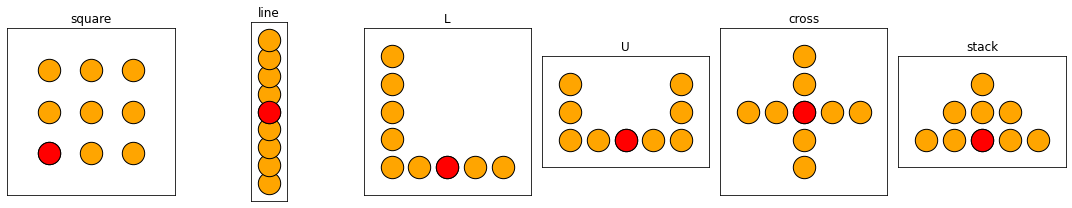

In [ ]:
import matplotlib.pyplot as plt


fig, axes = plt.subplots(1, len(GOAL_SHAPES), figsize=(15, 3))

for ax, (name, offsets) in zip(axes, GOAL_SHAPES.items()):
    xs = [x for x, y in offsets]
    ys = [y for x, y in offsets]
    
    ax.scatter(xs, ys, s=500, c='orange', edgecolors='black')
    # Highlight the red block at (0,0)
    ax.scatter([0], [0], s=500, c='red', edgecolors='black')
    
    ax.set_title(name)
    ax.set_aspect('equal')
    ax.invert_yaxis()
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_xlim(min(xs)-1, max(xs)+1)
    ax.set_ylim(min(ys)-1, max(ys)+1)

plt.tight_layout()
plt.show()